<div style="text-align: center; border: 2px solid #2E86C1; padding: 20px; border-radius: 10px; background-color: #FFFFFF;">

# Projet Machine Learning : Classification & Prédiction de la maladie de Parkinson
### *Analyse prédictive basée sur les données cliniques*

---

**Auteurs :** Sanfilippo Marco | Francine-Habas Mathis

**Institution :** ENAC | ISAE-SUPAERO | Université de Toulouse

**Année :** 2026-2027  

**UE :** Apprentissage automatique

---

### Résumé du Projet
Ce notebook est dédié ..

</div>

## 1.0 Le dataset

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
#!pip install ucimlrepo

In [8]:
# Import datasa
from ucimlrepo import fetch_ucirepo

datas_pks = fetch_ucirepo(id=189)

X = datas_pks.data.features
y = datas_pks.data.targets

#print(datas_pks.metadata)
#print(datas_pks.variables)
#print(datas_pks)

### 1.1. Explications du dataset

Le dataset étudié est lié au "Parkinsons Telemonitoring" et est divisé en deux parties principales :

- **`X` (features)** : C'est un DataFrame contenant les variables explications mesurées pour chaque sujet. Ces caractéristiques incluent l'âge, le sexe, le temps de test, différentes mesures vocales ou encore des indicateurs de la parole.

- **`y` (targets)** : C'est un DataFrame contenant les variables à prédire. Il s'agit ici des scores UPDRS (*Unified Parkinson's Disease Rating Scale*) :
    - `motor_UPDRS` : c'est le score qui évalue la gravité des symptômes moteurs de la maladie de Parkinson.
    - `total_UPDRS` : est une mesure globale de la sévérité de la maladie.

Chaque ligne représente une observation pour un sujet à un moment donné. Chaque patient est identifié par la colonne `.datas.ids`.

### 1.2. Aperçu des données et vérification du prétraitement

Il est tout d'abord nécessaire de vérifier la configuration du dataset et d'obtenir des informations sur les données stockées.

In [14]:
print(f"First lines of the features (X):\n")
display(X.head())

print("\nInformation on features (X):\n")
X.info()

print("\nPremières lignes des targets (y):\n")
display(y.head())

print("\nInformations sur les targets (y):\n")
y.info()

print("\nValeurs manquantes dans X:\n")
display(X.isnull().sum())

print("\nValeurs manquantes dans y:\n")
display(y.isnull().sum())

First lines of the features (X):



,age,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,sex
0,72,5.6431,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006,0
1,72,12.6660,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810,0
2,72,19.6810,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014,0
3,72,25.6470,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277,0
4,72,33.6420,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361,0



Information on features (X):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            5875 non-null   int64  
 1   test_time      5875 non-null   float64
 2   Jitter(%)      5875 non-null   float64
 3   Jitter(Abs)    5875 non-null   float64
 4   Jitter:RAP     5875 non-null   float64
 5   Jitter:PPQ5    5875 non-null   float64
 6   Jitter:DDP     5875 non-null   float64
 7   Shimmer        5875 non-null   float64
 8   Shimmer(dB)    5875 non-null   float64
 9   Shimmer:APQ3   5875 non-null   float64
 10  Shimmer:APQ5   5875 non-null   float64
 11  Shimmer:APQ11  5875 non-null   float64
 12  Shimmer:DDA    5875 non-null   float64
 13  NHR            5875 non-null   float64
 14  HNR            5875 non-null   float64
 15  RPDE           5875 non-null   float64
 16  DFA            5875 non-null   float64
 17  PPE            5875 n

,motor_UPDRS,total_UPDRS
0,28.199,34.398
1,28.447,34.894
2,28.695,35.389
3,28.905,35.810
4,29.187,36.375



Informations sur les targets (y):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   motor_UPDRS  5875 non-null   float64
 1   total_UPDRS  5875 non-null   float64
dtypes: float64(2)
memory usage: 91.9 KB

Valeurs manquantes dans X:



,0
age,0
test_time,0
Jitter(%),0
Jitter(Abs),0
Jitter:RAP,0
Jitter:PPQ5,0
Jitter:DDP,0
Shimmer,0
Shimmer(dB),0
Shimmer:APQ3,0



Valeurs manquantes dans y:



,0
motor_UPDRS,0
total_UPDRS,0


Au vu des premières analyses, nous pouvons observer qu'aucune donnée n'est manquante  dans les DataFrames `X` et `y`. De plus, toutes les colonnes sont numériques. Cependant, ... du prétaitement est nécessaire => standardisation ou normalisation + réalisation d'une ACP permettant de réduire la dimension du domaine.

### 1.3. Première analyse exhaustive du dataset


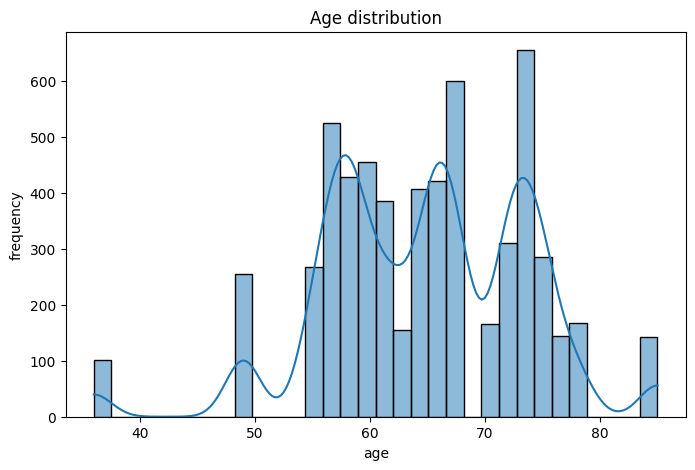

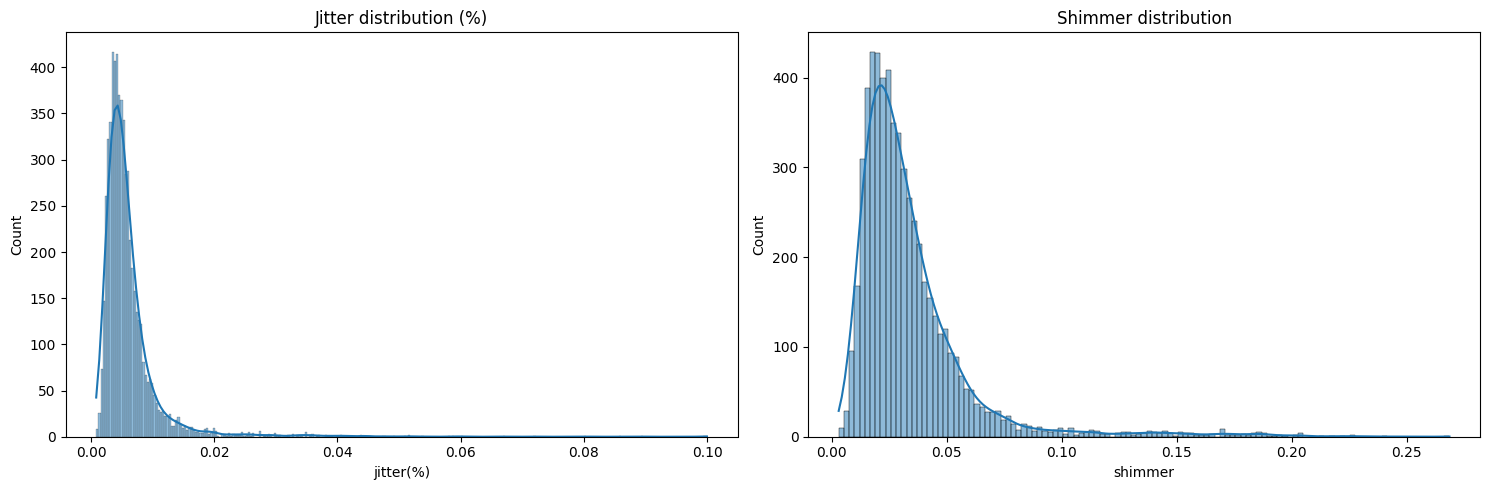

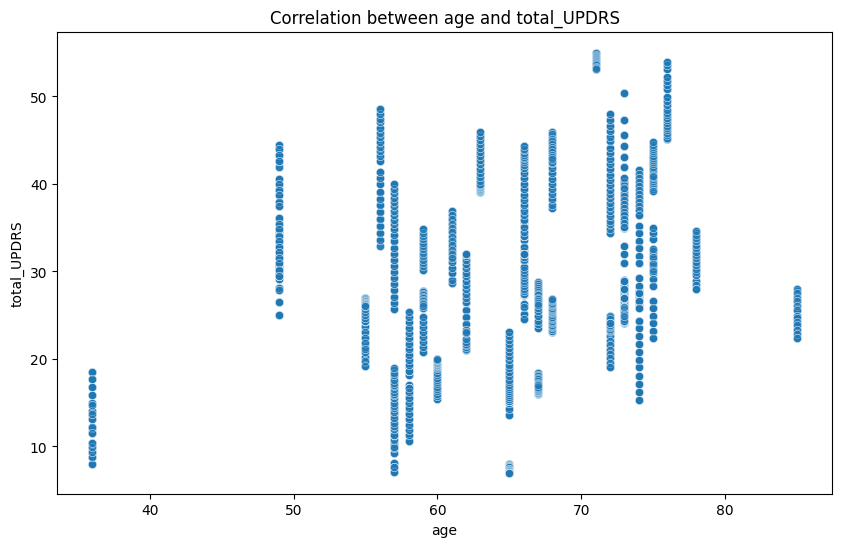

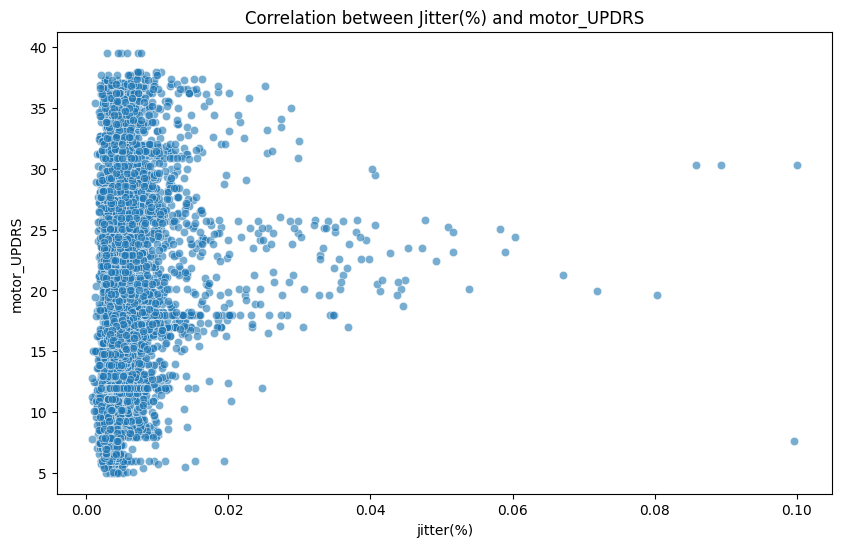

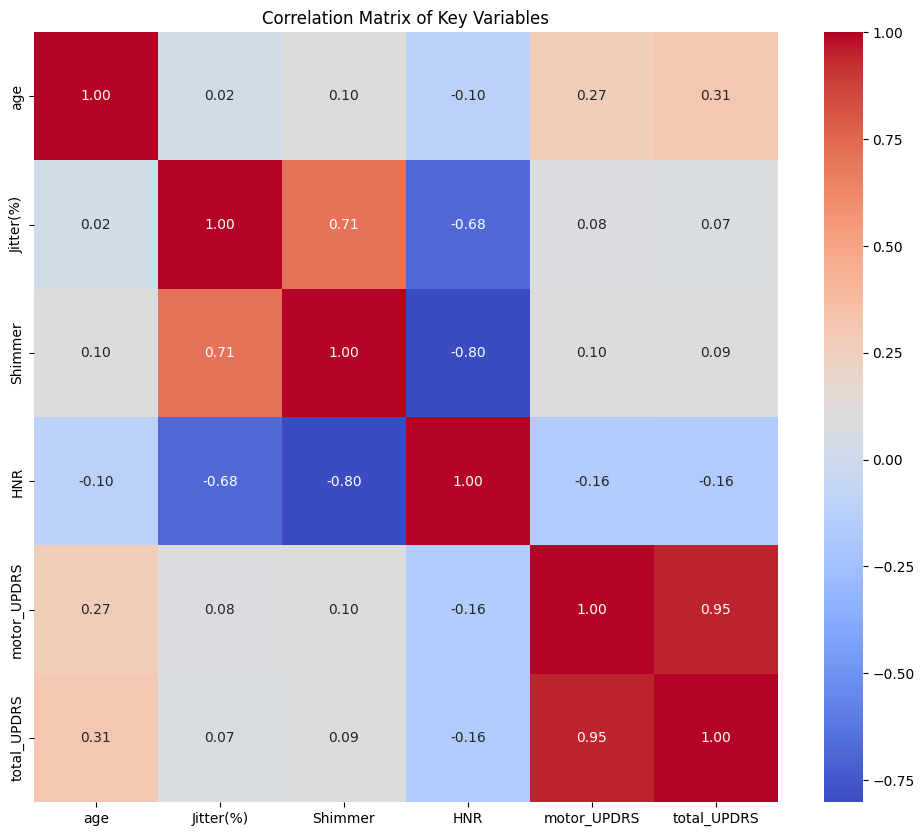

In [15]:

# Créer un DataFrame combiné pour faciliter la visualisation
df_combined = pd.concat([X, y], axis=1)

# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_combined['age'], kde=True)
plt.title("Age distribution")
plt.xlabel("age")
plt.ylabel("frequency")
plt.show()

# Distribution of a few vocal variables
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_combined['Jitter(%)'], kde=True)
plt.title("Jitter distribution (%)")
plt.xlabel("jitter(%)")

plt.subplot(1, 2, 2)
sns.histplot(df_combined['Shimmer'], kde=True)
plt.title("Shimmer distribution")
plt.xlabel("shimmer")

plt.tight_layout()
plt.show()

# Correlation between age and total_UPDRS
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='total_UPDRS', data=df_combined, alpha=0.6)
plt.title("Correlation between age and total_UPDRS")
plt.xlabel("age")
plt.ylabel("total_UPDRS")
plt.show()

# Correlation between Jitter(%) and motor_UPDRS
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Jitter(%)', y='motor_UPDRS', data=df_combined, alpha=0.6)
plt.title("Correlation between Jitter(%) and motor_UPDRS")
plt.xlabel("jitter(%)")
plt.ylabel("motor_UPDRS")
plt.show()

# Correlation matrix between some variables
plt.figure(figsize=(12, 10))
correlation_matrix = df_combined[['age', 'Jitter(%)', 'Shimmer', 'HNR', 'motor_UPDRS', 'total_UPDRS']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Key Variables")
plt.show()

**Interprétation :**

### Références
* <a id="ref1"></a>[1] **Tsanas, A. & Little, M.** (2009). *Parkinsons Telemonitoring*. UCI Machine Learning Repository. https://doi.org/10.24432/C5ZS3N.